In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_updated.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_updated_clipped.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

2026-03-24 20:26:09.367313: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 20:26:09.420523: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 20:26:10.879575: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 20:26:10.882158: I external/local_xla/xla/tsl/cuda/cudart

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

# Bright spot

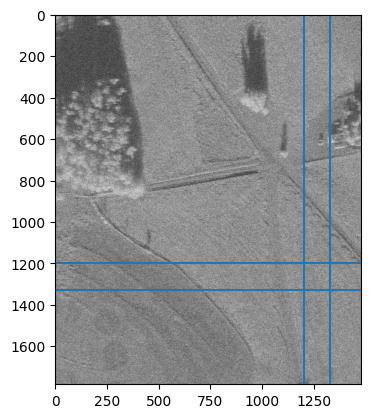

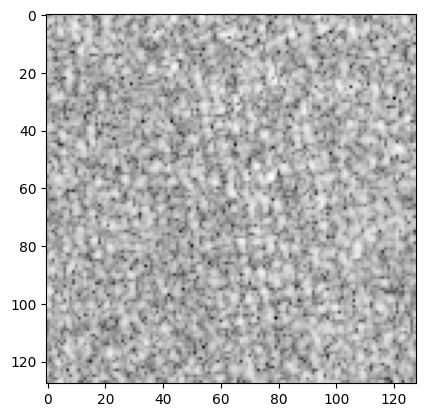

In [4]:
xk = 1200
yk = 1200

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [5]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
meas_ds_path = [meas_ds.samples[i][0] for i in range(len(meas_ds))]

In [7]:
clutter_cache1 = {file: (os.path.join(clutter_dir, 'HB06158'), 1200, 1200) for file in meas_ds_path}

In [8]:
meas_ds_s2_1 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache1), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

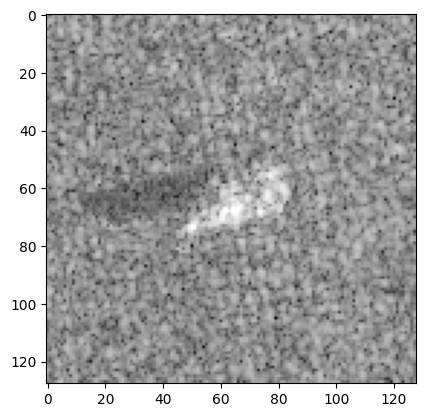

In [9]:
plt.imshow(meas_ds_s2_1[0][0][0], cmap = "grey")
plt.show()

In [10]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [11]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds_s2_1, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.8639
Evaluating Run 1: seed 42
Test Accuracy: 0.8550
Evaluating Run 2: seed 100
Test Accuracy: 0.8357
Evaluating Run 3: seed 123
Test Accuracy: 0.8238
Evaluating Run 4: seed 666
Test Accuracy: 0.8015
Evaluating Run 5: seed 777
Test Accuracy: 0.8461
Evaluating Run 6: seed 849
Test Accuracy: 0.8736
Evaluating Run 7: seed 1000
Test Accuracy: 0.8364
Evaluating Run 8: seed 1111
Test Accuracy: 0.8602
Evaluating Run 9: seed 1234
Test Accuracy: 0.8996


In [12]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 80.1487
Max: 89.9628
Avg, Std: 84.9591, 2.6052


# Dark spot

In [13]:
clutter_cache2 = {file: (os.path.join(clutter_dir, 'HB06158'), 100, 100) for file in meas_ds_path}

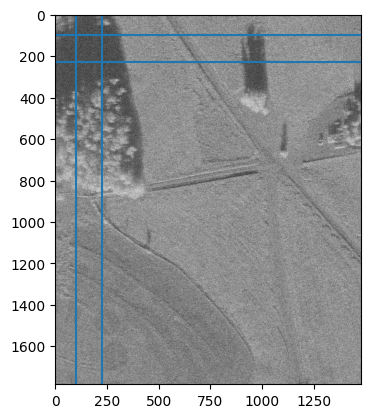

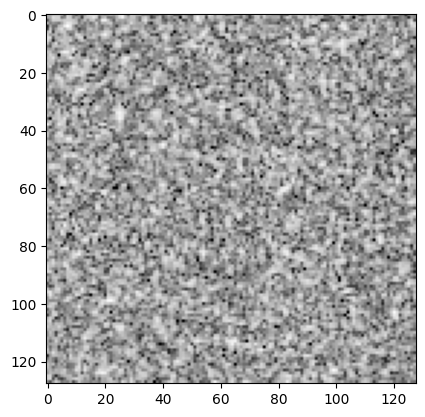

In [14]:
xk = 100
yk = 100

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [15]:
meas_ds_s2_2 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache2), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

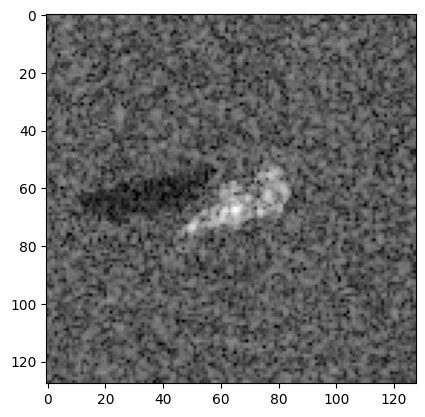

In [16]:
plt.imshow(meas_ds_s2_2[0][0][0], cmap = "grey")
plt.show()

In [17]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [18]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds_s2_2, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.9212
Evaluating Run 1: seed 42
Test Accuracy: 0.9160
Evaluating Run 2: seed 100
Test Accuracy: 0.9115
Evaluating Run 3: seed 123
Test Accuracy: 0.8959
Evaluating Run 4: seed 666
Test Accuracy: 0.8803
Evaluating Run 5: seed 777
Test Accuracy: 0.8840
Evaluating Run 6: seed 849
Test Accuracy: 0.9123
Evaluating Run 7: seed 1000
Test Accuracy: 0.9041
Evaluating Run 8: seed 1111
Test Accuracy: 0.9167
Evaluating Run 9: seed 1234
Test Accuracy: 0.9093


In [19]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 88.0297
Max: 92.1190
Avg, Std: 90.5130, 1.3297


# Mixed

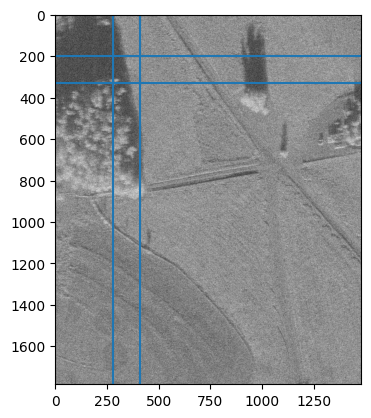

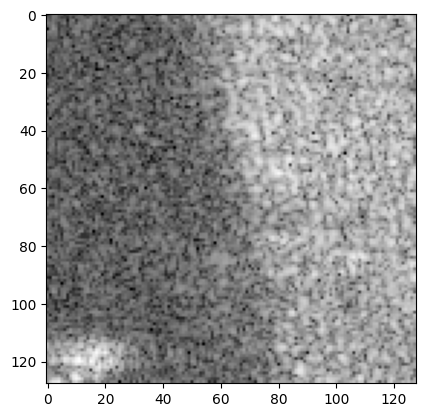

In [20]:
xk = 280
yk = 200

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [21]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [22]:
meas_ds_path = [meas_ds.samples[i][0] for i in range(len(meas_ds))]

clutter_cache3 = {file: (os.path.join(clutter_dir, 'HB06158'), 200, 280) for file in meas_ds_path}

In [23]:
meas_ds_s2_3 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

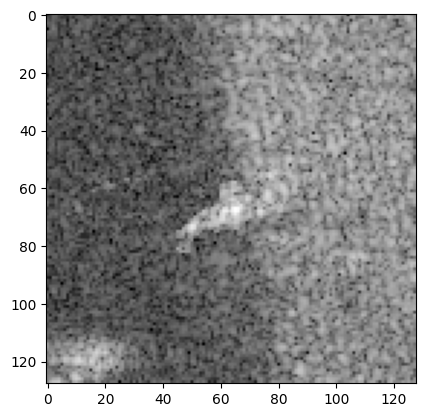

In [24]:
plt.imshow(meas_ds_s2_3[0][0][0], cmap = "grey")
plt.show()

In [25]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds_s2_3, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.6833
Evaluating Run 1: seed 42
Test Accuracy: 0.7197
Evaluating Run 2: seed 100
Test Accuracy: 0.6535
Evaluating Run 3: seed 123
Test Accuracy: 0.6461
Evaluating Run 4: seed 666
Test Accuracy: 0.5740
Evaluating Run 5: seed 777
Test Accuracy: 0.6431
Evaluating Run 6: seed 849
Test Accuracy: 0.6416
Evaluating Run 7: seed 1000
Test Accuracy: 0.6409
Evaluating Run 8: seed 1111
Test Accuracy: 0.6164
Evaluating Run 9: seed 1234
Test Accuracy: 0.6617


In [26]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 57.3978
Max: 71.9703
Avg, Std: 64.8030, 3.6336
